In [3]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def read_final_cell(filename):
    text = Path(filename).read_text(errors="ignore")

    blocks = re.findall(
        r"CELL_PARAMETERS\s*\(angstrom\)\s*\n"
        r"\s*([-\d.Ee+]+)\s+([-\d.Ee+]+)\s+([-\d.Ee+]+)\s*\n"
        r"\s*([-\d.Ee+]+)\s+([-\d.Ee+]+)\s+([-\d.Ee+]+)\s*\n"
        r"\s*([-\d.Ee+]+)\s+([-\d.Ee+]+)\s+([-\d.Ee+]+)",
        text
    )

    if not blocks:
        return None

    values = np.array(blocks[-1], dtype=float)
    return values.reshape(3, 3)


def read_final_fe_magnetization(filename, atom_number=106):
    text = Path(filename).read_text(errors="ignore")

    pattern = rf"atom\s+{atom_number}\s+\(R=.*?\)\s+charge=\s*[-\d.Ee+]+\s+magn=\s*([-\d.Ee+]+)"

    matches = re.findall(pattern, text)

    if not matches:
        return np.nan

    return float(matches[-1])


def cell_parameters(cell):
    a_vec, b_vec, c_vec = cell

    a = np.linalg.norm(a_vec)
    b = np.linalg.norm(b_vec)
    c = np.linalg.norm(c_vec)

    alpha = np.degrees(np.arccos(np.dot(b_vec, c_vec) / (b * c)))
    beta  = np.degrees(np.arccos(np.dot(a_vec, c_vec) / (a * c)))
    gamma = np.degrees(np.arccos(np.dot(a_vec, b_vec) / (a * b)))

    return a, b, c, alpha, beta, gamma


def primitive_to_conventional_C2c(cell_prim):
    p1, p2, p3 = cell_prim

    A = p1 + p2
    B = p2 - p1
    C = p3

    return np.array([A, B, C])


rows = []

pressures = [round(x, 1) for x in np.arange(0.1, 1.01, 0.1)]
pressures += list(range(2, 16))

for P in pressures:
    folder = f"{P:g}Kbar"

    for spin in ["HS", "LS"]:
        outfile = Path(folder) / spin / f"vc_relax_{spin}.out"

        if not outfile.exists():
            print(f"Arquivo não encontrado: {outfile}")
            continue

        cell_prim = read_final_cell(outfile)

        if cell_prim is None:
            print(f"CELL_PARAMETERS não encontrado: {outfile}")
            continue

        cell_conv = primitive_to_conventional_C2c(cell_prim)
        a, b, c, alpha, beta, gamma = cell_parameters(cell_conv)

        mag_fe = read_final_fe_magnetization(outfile, atom_number=106)

        rows.append({
            "P_kbar": P,
            "spin": spin,
            "a": a,
            "b": b,
            "c": c,
            "alpha": alpha,
            "beta": beta,
            "gamma": gamma,
            "Fe_magn_atom106": mag_fe
        })


df = pd.DataFrame(rows)
df = df.sort_values(["spin", "P_kbar"])

#print(df)

df.to_csv("cell_parameters_and_Fe_magnetization_vs_pressure.csv", index=False)


params = ["a", "b", "c", "alpha", "beta", "gamma"]
ylabs = {
    "a": r"$a$ ($\AA$)",
    "b": r"$b$ ($\AA$)",
    "c": r"$c$ ($\AA$)",
    "alpha": r"$\alpha$ (deg)",
    "beta": r"$\beta$ (deg)",
    "gamma": r"$\gamma$ (deg)"
}

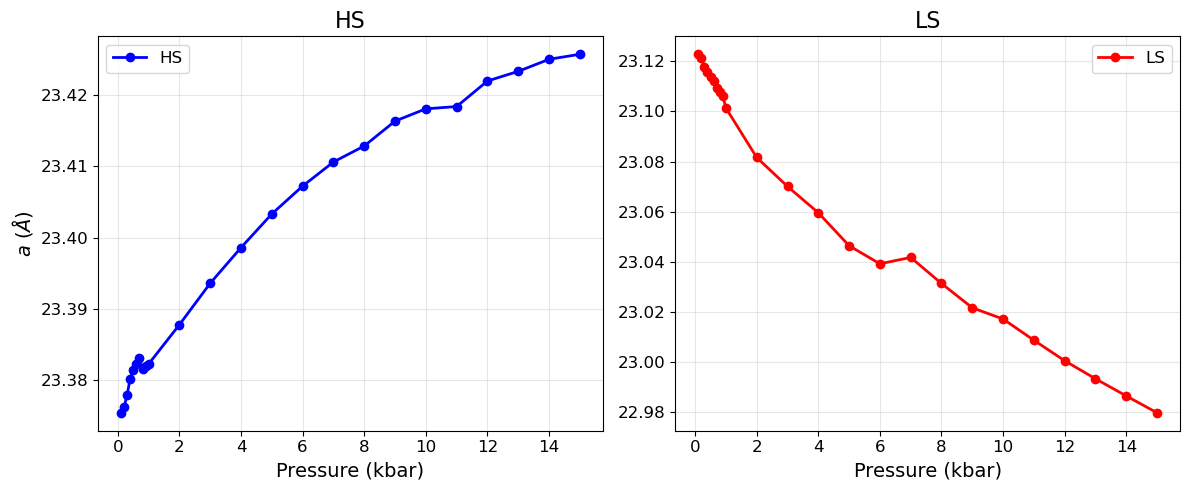

In [39]:
hs = df[df["spin"] == "HS"]
ls = df[df["spin"] == "LS"]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=False
)

ax1.plot(
    hs["P_kbar"],
    hs["a"],
    marker="o",
    linewidth=2,
    label="HS",
    color='blue'
)

ax2.plot(
    ls["P_kbar"],
    ls["a"],
    marker="o",
    linewidth=2,
    label="LS",
    color='red'
)

ax1.set_title("HS", fontsize=16)
ax2.set_title("LS", fontsize=16)

ax1.set_xlabel("Pressure (kbar)", fontsize=14)
ax2.set_xlabel("Pressure (kbar)", fontsize=14)

ax1.set_ylabel(r"$a$ ($\AA$)", fontsize=14)

ax1.tick_params(axis="both", labelsize=12)
ax2.tick_params(axis="both", labelsize=12)

ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

ax1.legend(fontsize=12)
ax2.legend(fontsize=12)

fig.tight_layout()

#fig.savefig("lattice_a_HS_LS_panels.pdf", dpi=300)
#fig.savefig("lattice_a_HS_LS_panels.png", dpi=300)

plt.show()

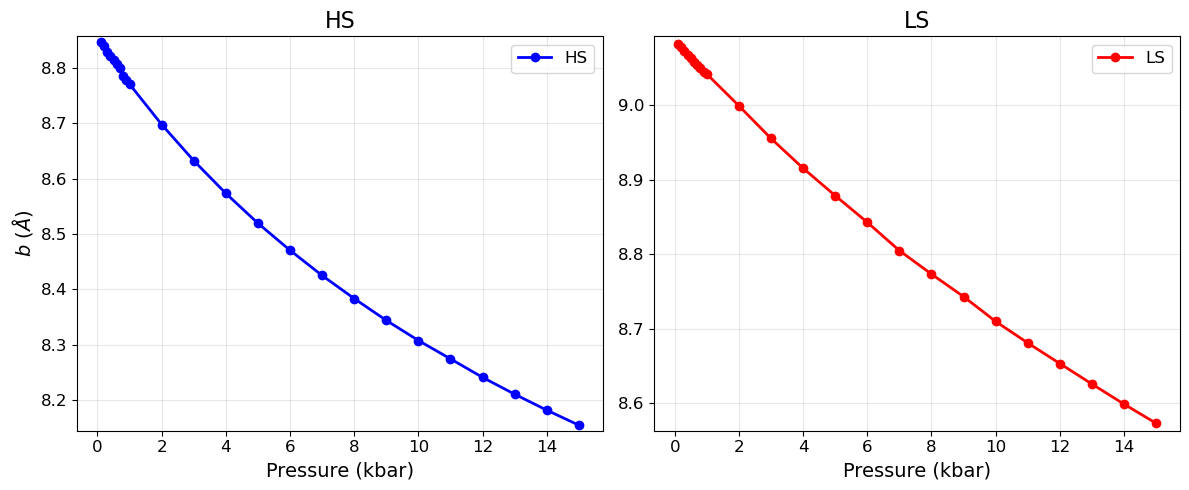

In [40]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=False
)

ax1.plot(hs["P_kbar"], hs["b"], marker="o", linewidth=2, label="HS",color='blue')
ax2.plot(ls["P_kbar"], ls["b"], marker="o", linewidth=2, label="LS",color='red')

ax1.set_title("HS", fontsize=16)
ax2.set_title("LS", fontsize=16)

ax1.set_xlabel("Pressure (kbar)", fontsize=14)
ax2.set_xlabel("Pressure (kbar)", fontsize=14)

ax1.set_ylabel(r"$b$ ($\AA$)", fontsize=14)

ax1.tick_params(axis="both", labelsize=12)
ax2.tick_params(axis="both", labelsize=12)

ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

ax1.legend(fontsize=12)
ax2.legend(fontsize=12)

ax1.set_ylim(min(hs["b"])-0.01,max(hs["b"])+0.01)
ax2.set_ylim(min(ls["b"])-0.01,max(ls["b"])+0.01)

fig.tight_layout()

#fig.savefig("lattice_b_HS_LS_panels.pdf", dpi=300)
#fig.savefig("lattice_b_HS_LS_panels.png", dpi=300)

plt.show()

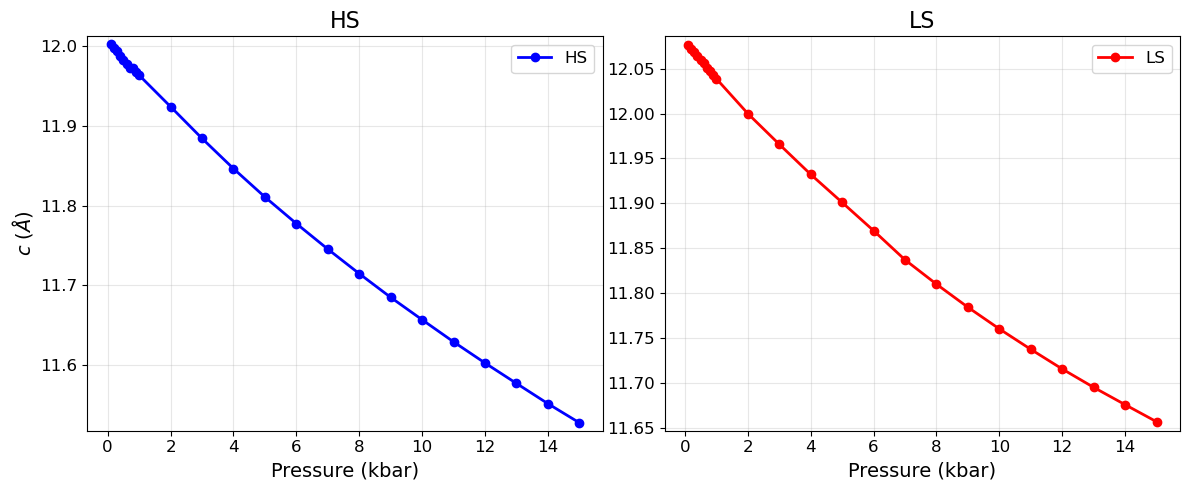

In [41]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=False
)

ax1.plot(hs["P_kbar"], hs["c"], marker="o", linewidth=2, label="HS",color='blue')
ax2.plot(ls["P_kbar"], ls["c"], marker="o", linewidth=2, label="LS",color='red')

ax1.set_title("HS", fontsize=16)
ax2.set_title("LS", fontsize=16)

ax1.set_xlabel("Pressure (kbar)", fontsize=14)
ax2.set_xlabel("Pressure (kbar)", fontsize=14)

ax1.set_ylabel(r"$c$ ($\AA$)", fontsize=14)

ax1.tick_params(axis="both", labelsize=12)
ax2.tick_params(axis="both", labelsize=12)

ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)

ax1.legend(fontsize=12)
ax2.legend(fontsize=12)

fig.tight_layout()
ax1.set_ylim(min(hs["c"])-0.01,max(hs["c"])+0.01)
ax2.set_ylim(min(ls["c"])-0.01,max(ls["c"])+0.01)

#fig.savefig("lattice_c_HS_LS_panels.pdf", dpi=300)
#fig.savefig("lattice_c_HS_LS_panels.png", dpi=300)

plt.show()

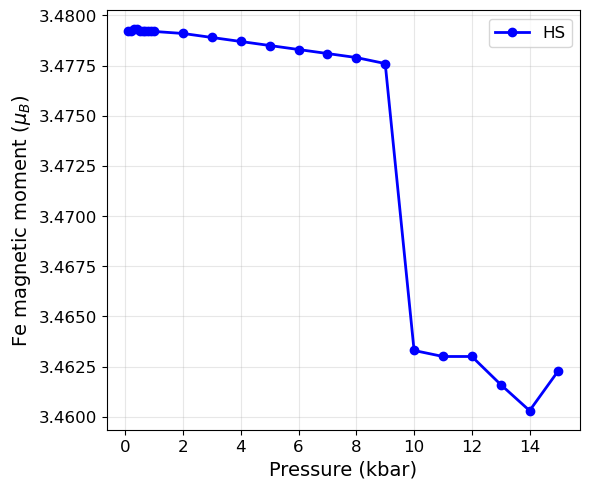

In [42]:
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ax.plot(
    hs["P_kbar"],
    hs["Fe_magn_atom106"],
    marker="o",
    linewidth=2,
    label="HS",
    color='blue'
)

ax.set_xlabel("Pressure (kbar)", fontsize=14)
ax.set_ylabel(r"Fe magnetic moment ($\mu_B$)", fontsize=14)

ax.tick_params(axis="both", labelsize=12)

ax.grid(True, alpha=0.3)

ax.legend(fontsize=12)

fig.tight_layout()

plt.show()